https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html </br>
https://github.com/scikit-learn/scikit-learn/blob/fe2edb3cd/sklearn/ensemble/_iforest.py#L55 </br>
https://www.geeksforgeeks.org/machine-learning/what-is-isolation-forest/ </br>
https://www.datacamp.com/tutorial/isolation-forest </br>
https://pyimagesearch.com/2024/10/21/predictive-maintenance-using-isolation-forest/


# **IsolationForest** </br>

1) class sklearn.ensemble.IsolationForest(*, n_estimators=100, max_samples='auto', contamination='auto', max_features=1.0, bootstrap=False, n_jobs=None, random_state=None, verbose=0, warm_start=False)
</br>
2) (i) Return the anomaly score of each sample using the *IsolationForest* algorithm. (ii) The IsolationForest ‘isolates’ observations by randomly selecting a feature and then randomly selecting a split value between the maximum and minimum values of the selected feature. (iii) Partitioning: Data is split using randomly selected features and random threshold values. These random splits efficiently separate anomalies from normal data. (iv) Anomaly Score: The anomaly score represents how easily a data point can be isolated. Fewer splits mean a higher anomaly score, hence a greater likelihood of being an outlier.

In [1]:
#Importing required libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

#Load Sample Dataset & Pre-processing

(1) A Credit Card Anomaly detection dataset (284,808 rows) for its implementation and limit its row count to 40,000 for faster processing. </br>
(2) Standardise the features of the dataset excluding the target variable 'Class' using StandardScaler.

In [3]:
credit_data = pd.read_csv('/content/creditcard.csv', nrows=40000)
#Dataset can be downloaded from https://www.geeksforgeeks.org/machine-learning/what-is-isolation-forest/

In [4]:
scaler = StandardScaler().fit_transform(credit_data.loc[:,credit_data.columns!='Class'])
scaled_data = scaler[0:40000]
df = pd.DataFrame(data=scaled_data)
X = credit_data.drop(columns=['Class'])
y = credit_data['Class']

In [35]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [31]:
print(X)

        Time        V1        V2        V3        V4        V5        V6  \
0          0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388   
1          0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361   
2          1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
3          1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4          2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921   
...      ...       ...       ...       ...       ...       ...       ...   
39697  39927 -1.466679  2.425732  0.877724  3.950765  0.762477  1.162748   
39698  39927 -0.523165 -0.100021  0.892966 -1.900405 -0.156870 -0.783894   
39699  39928 -2.768425 -1.007072  2.151127  0.117797  1.283178  1.869731   
39700  39928  1.201327  0.158614 -0.325263  0.471667  0.086446 -0.770357   
39701  39929  1.097669 -1.315782  0.659681 -0.683915 -1.342612  0.332629   

             V7        V8        V9  ...       V20       V21       V22  \
0      0.2395

#Model Making

The fraction of outliers is calculated by looking at the number of fraudulent transactions in the dataset then we create and fit the Isolation Forest model with this outlier fraction. </br>

*   n_estimators=100: Number of trees in the ensemble (improves accuracy).
*   contamination: Fraction of outliers in data, helps model set detection threshold.
* sample_size is the number of instances used to train each Isolation Tree. A value of 256 is commonly used as it allows us to avoid using a maximum tree size stopping criteria. This is because we can expect reasonable maximum tree sizes of log(256) = 8.
* random_state=42: Ensures reproducible results.

In [36]:
### Train the Isolation Forest

outlier_fraction = len(credit_data[credit_data['Class']==1])/float(len(credit_data[credit_data['Class']==0]))
#sample_size = 256

#model =  IsolationForest(n_estimators=100, contamination=outlier_fraction, max_samples=sample_size, random_state=42)
model =  IsolationForest(n_estimators=100, contamination=outlier_fraction, random_state=42)
model.fit(x_train)


IsolationForest(contamination=0.00262646160062631, random_state=42)

#Model Making

Evaluate the model’s performance by calculating its accuracy in detecting anomalies (fraudulent transactions) based on the anomaly scores.



*   Decision Function: Computes anomaly scores for each point.
*   Prediction Adjustment: Converts predictions (1 = normal, -1 = anomaly) to match dataset labels.
* Accuracy Calculation: Measures detection rate of anomalies.

In [60]:
scores_prediction = model.decision_function(x_train)
print(scores_prediction)

In [62]:
y_pred = model.predict(x_test)
y_pred[y_pred == 1] = 0
y_pred[y_pred == -1] = 1

In [56]:
print("Accuracy in finding anomaly:",accuracy_score(y_test, y_pred))

Accuracy in finding anomaly: 0.998069011837797


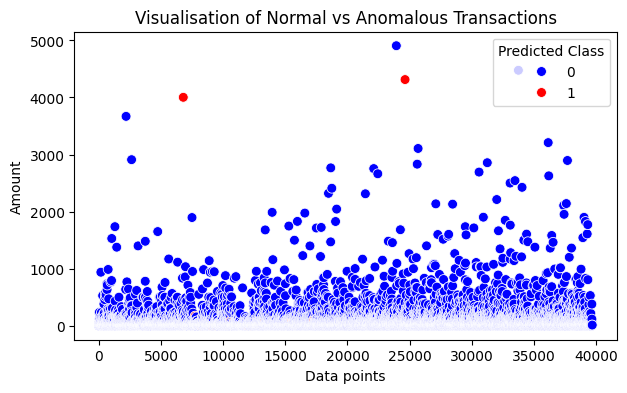

In [70]:
# Visualise the model

y_feature = x_test['Amount']
x_test['predicted_class'] = y_pred

plt.figure(figsize=(7, 4))
sns.scatterplot(x=credit_data.index, y=y_feature, hue=credit_data['predicted_class'], palette={0: 'blue', 1: 'red'}, s=50)
plt.title('Visualisation of Normal vs Anomalous Transactions')
plt.xlabel('Data points')
plt.ylabel(y_feature.name)
plt.legend(title='Predicted Class', loc='best')
plt.show()